In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.constants import h, k
import os
import random

import scienceplots as splt
matplotlib.pyplot.style.use(['science', 'notebook', 'ieee'])
matplotlib.pyplot.rcParams['font.family'] = 'Times New Roman'


project_root = Path.cwd().parent.parent  
sys.path.append(str(project_root / "src"))

import utils as ut
from saving import save_figure_in_images
from molecules.molecule import CaH, CaOH, CaOH_dm2, CaH_dm2, Molecule
import QLS.spectrum as spectrum
import QLS.pumping as pumping
import QLS.state_dist as state_dist

## Quantum Logic Spectroscopy

Saved molecule data in:
/home/stripzio/bayesian-qls/project/molecule_data/CaOH_B[3.27]_Jmax[50]_states.csv
/home/stripzio/bayesian-qls/project/molecule_data/CaOH_B[3.27]_Jmax[50]_transitions.csv
Saved figure in: /home/stripzio/bayesian-qls/project/images/unpumped_pumped_caoh.svg


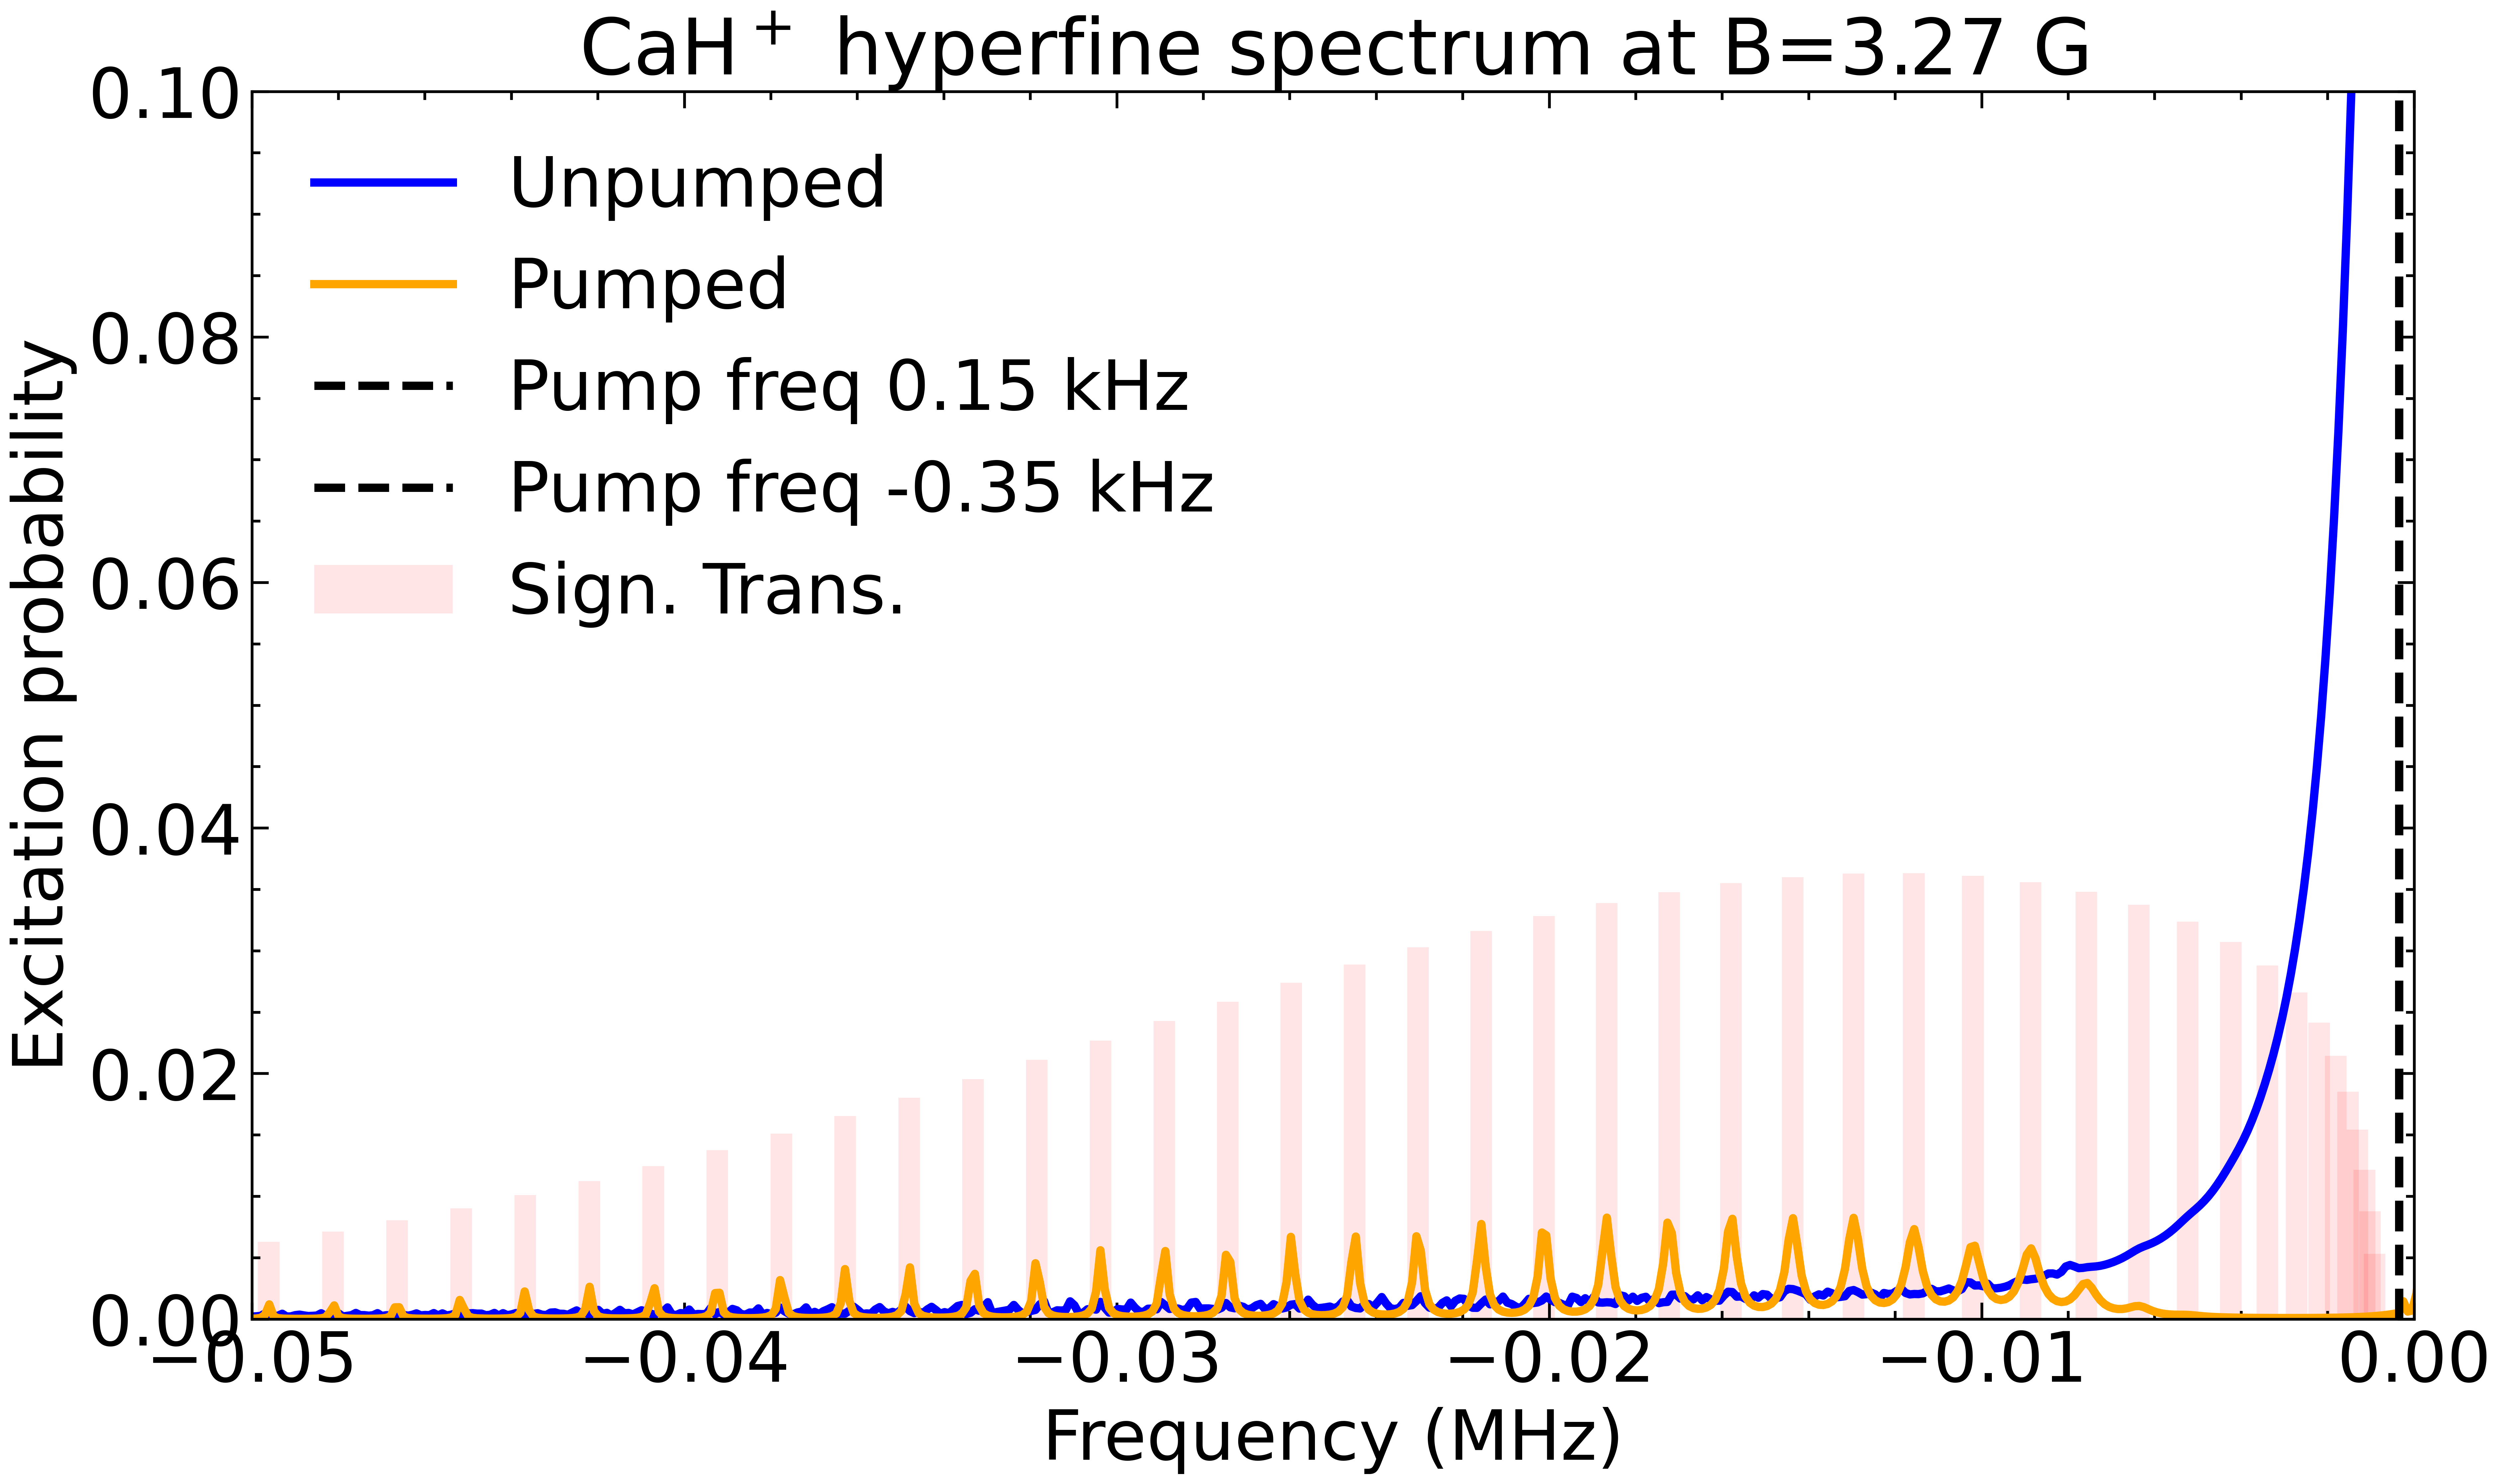

In [2]:
b_field_gauss = 3.27
j_max = 50

mo1 = CaOH.create_molecule_data(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states = state_dist.States(mo1, temperature)

spectrum_list = {
    "duration_us": 5000.0,
    "rabi_rate_mhz": 2*np.pi*0.005,
    "max_frequency_mhz": 0.05,        # 50 kHz
    "scan_points": 1000,
    "dephased" : True,
    "coherence_time_us": 100,
    "is_minus" : True
}


pump_sequences = [
    {
        "frequency_mhz": 0.00015,
        "num_pumps": 1000,
        "duration_us": 1000.0,
        "rabi_rate_mhz": 2*np.pi*0.005,
        "dephased": False,
        "coherence_time_us": 100,
        "is_minus": True,
    },
    {
        "frequency_mhz": -0.00035,
        "num_pumps": 1000,
        "duration_us": 1000.0,
        "rabi_rate_mhz": 2*np.pi*0.005,
        "dephased": True,
        "coherence_time_us": 100,
        "is_minus": True,
    }
]



spectrum.unpumped_pumped(b_field_gauss, j_max, mo1, states, spectrum_list, pump_sequences, 
                         filename = "unpumped_pumped_caoh.svg", y_lim=0.1)

Unpumped spectrum alone, were we only changed the rabi rate

Saved molecule data in:
/home/stripzio/bayesian-qls/project/molecule_data/CaOH_B[3.27]_Jmax[50]_states.csv
/home/stripzio/bayesian-qls/project/molecule_data/CaOH_B[3.27]_Jmax[50]_transitions.csv
Saved figure in: /home/stripzio/bayesian-qls/project/images/unpumped_wo_imperf_caoh.svg


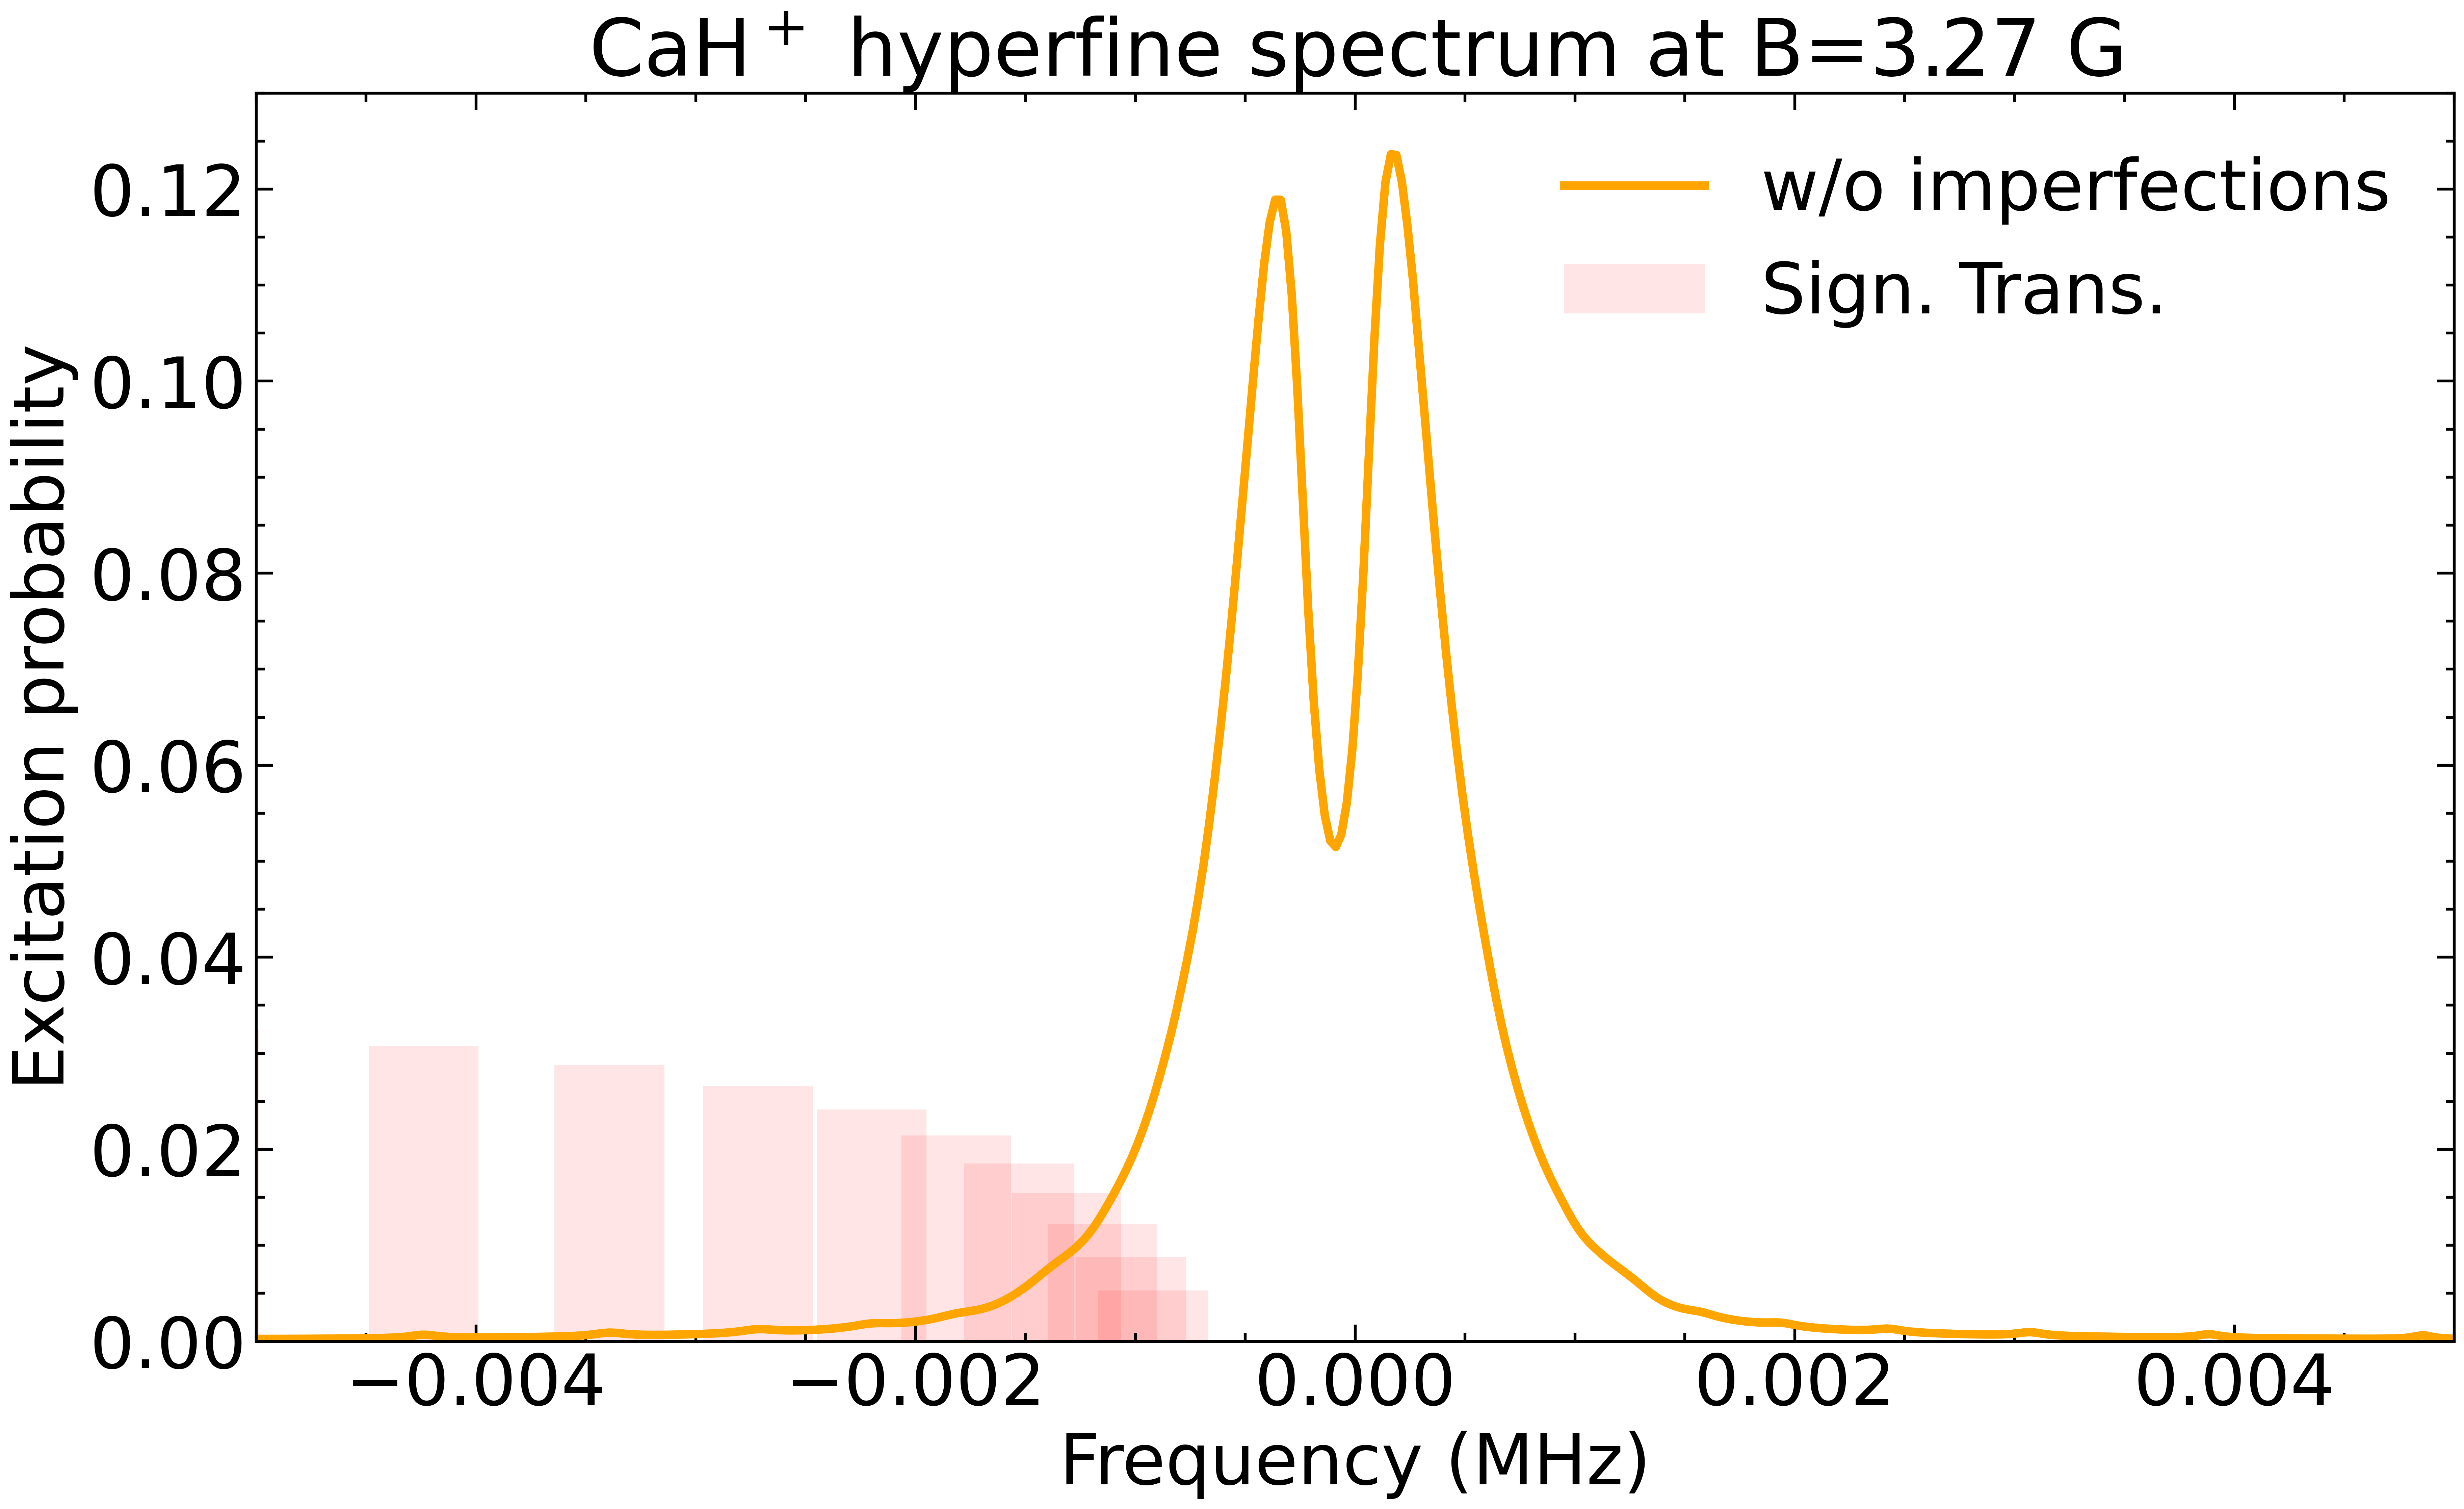

In [3]:
b_field_gauss = 3.27
j_max = 50

mo1 = CaOH.create_molecule_data(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states = state_dist.States(mo1, temperature)

spectrum_list = {
    "duration_us": 5000.0,
    "rabi_rate_mhz": 0.005,
    "max_frequency_mhz": 0.005,        # 50 kHz
    "scan_points": 400,
    "dephased" : True,
    "coherence_time_us": 100,
    "is_minus" : True
}


spectrum.spectrum_w_wo_imperfections(b_field_gauss, j_max, mo1, states, spectrum_list, scan_direction="both", pump_sequences=None,
                            noise_params=None, laser_miscalibration=None, 
                            seed_miscalibration=None, false_positive_rate=0.0,
                            filename = "unpumped_wo_imperf_caoh.svg", y_lim = 0.13)

## Unpumped spectrum without ODF - with experimental imperfections

In this part we will compute the unpumped spectrum for CaOH molecule without the ODF and with the experimental imperfections. The comparison with the case of having experimental imperfections is also reported. 

In particular we have:

- laser miscalibration on frequency gaussian distributed with sigma = 50 Hz and rabi rate gaussian distributed with a sigma to be the 10% of its nominal value. constant throughout the whole run
- shot-to-shot fluctuations on frequency gaussian distributed with sigma = 30 Hz and rabi rate gaussian distributed with a sigma to be the 1% of its nominal value. changes at each pulse
- false positive rate uniformly distributed to be 1.5%

Saved molecule data in:
/home/stripzio/bayesian-qls/project/molecule_data/CaOH_B[3.27]_Jmax[50]_states.csv
/home/stripzio/bayesian-qls/project/molecule_data/CaOH_B[3.27]_Jmax[50]_transitions.csv
Saved figure in: /home/stripzio/bayesian-qls/project/images/unpumped_w_wo_imperf_caoh.svg


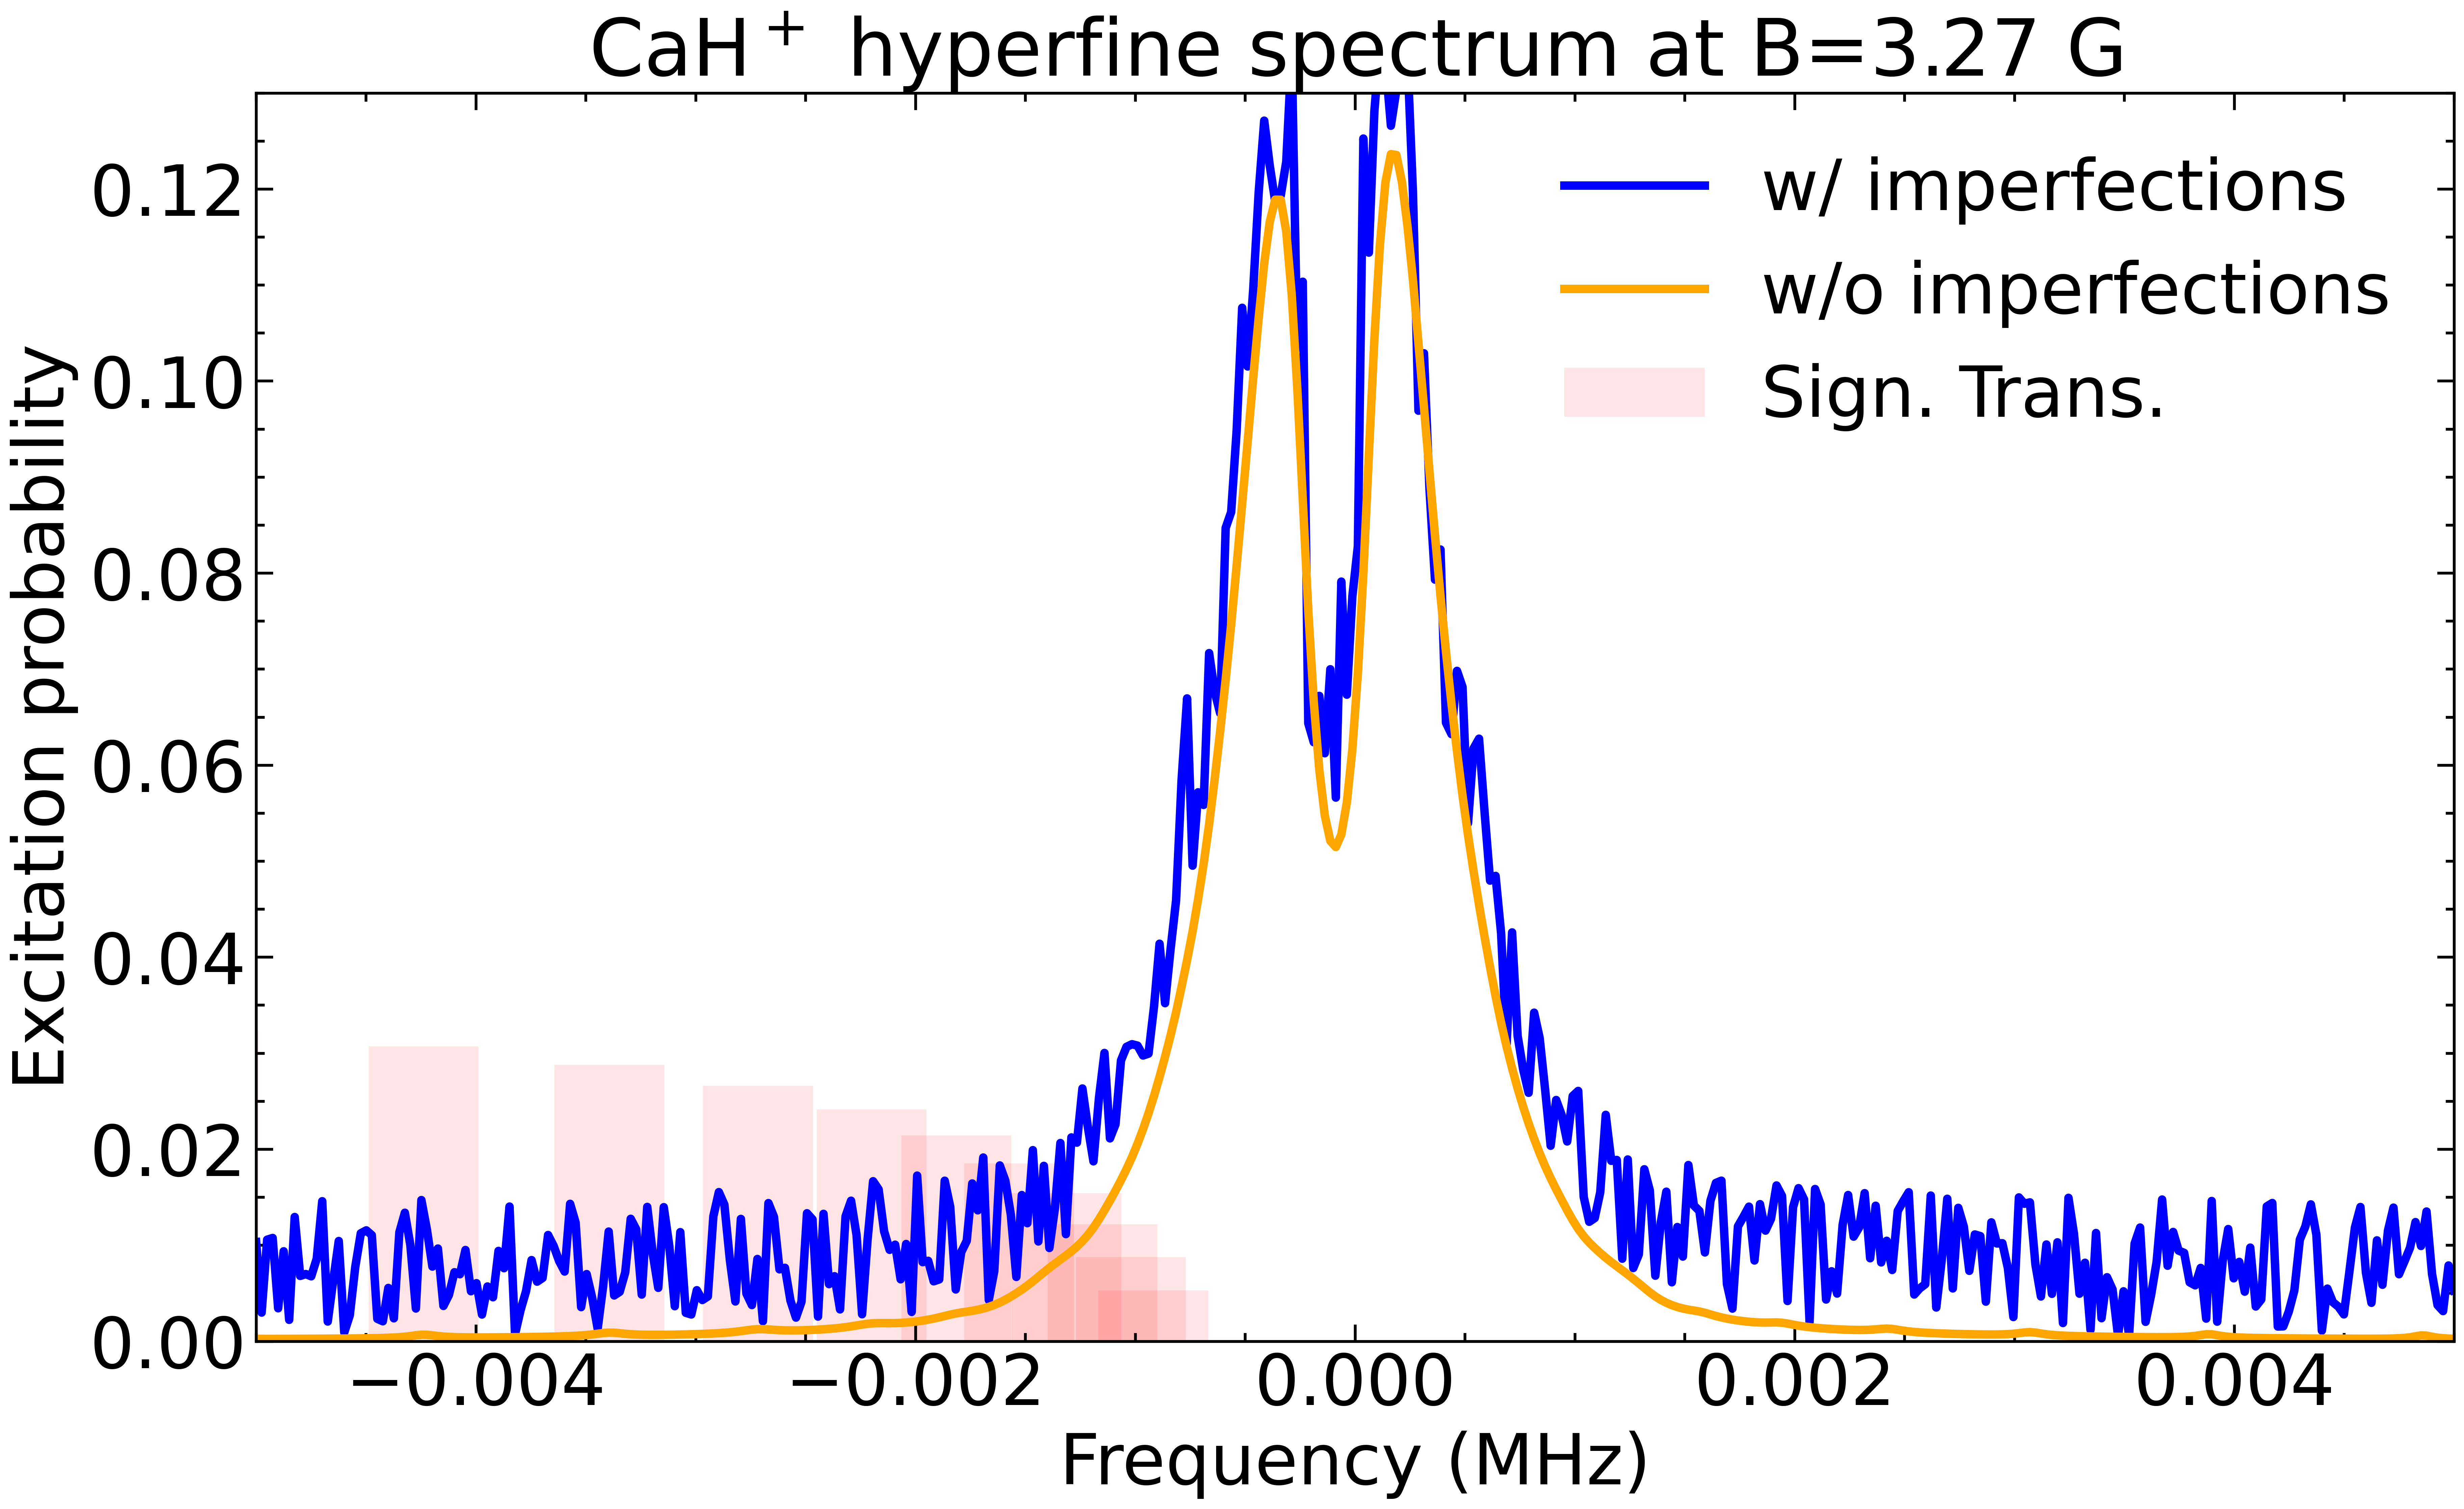

In [4]:
b_field_gauss = 3.27
j_max = 50

mo1 = CaOH.create_molecule_data(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states = state_dist.States(mo1, temperature)

spectrum_list = {
    "duration_us": 5000.0,
    "rabi_rate_mhz": 0.005,
    "max_frequency_mhz": 0.005,        # 50 kHz
    "scan_points": 400,
    "dephased" : True,
    "coherence_time_us": 100,
    "is_minus" : True
}

laser_miscalibration = {
    "frequency": {"type": "abs_gaussian", "level": 0.00005},
    "rabi_rate": {"type": "rel_gaussian", "level": 0.1}
}

seed_miscalibration = random.randint(0, 10000)

noise_params = {
    "frequency": {"type": "abs_gaussian", "level": 0.00003},
    "rabi_rate": {"type": "rel_gaussian", "level": 0.01}
}

false_positive_rate = 0.015


spectrum.spectrum_w_wo_imperfections(b_field_gauss, j_max, mo1, states, spectrum_list, scan_direction="both", pump_sequences=None,
                            noise_params=noise_params, laser_miscalibration=laser_miscalibration, 
                            seed_miscalibration=seed_miscalibration, false_positive_rate=false_positive_rate,
                            filename = "unpumped_w_wo_imperf_caoh.svg", y_lim = 0.13)